## CS4243 Lab 3: Image Segmentation and Texture Description

**DEADLINE: April 1st, 22:00**

### Submission

Submit to Canvas a **single zip** `AXXX1_AXXX2.zip` containing:
1. `lab3.py` — your completed implementation
2. `lab3.ipynb` — this notebook **with all cells executed**

**Before submitting**, run **Kernel → Restart & Run All** to ensure your notebook runs from top to bottom without errors. The TA grades based on the **cell outputs** at each **[CP X.X]** checkpoint and the implementation in lab3.py.

### Rules

- Implement all functions in `lab3.py`. Do **not** change function signatures.
- You may use NumPy freely; do **not** use OpenCV functions beyond those in the template.
- Do **not** rename or restructure files.
- For open questions, write answers directly in the designated markdown cells.
- As long as your output is close to the expected answer, you will get full credit.

### Overview

| Part | Topic | Weight |
|---|---|---|
| **Part 1** | Mean-Shift Segmentation (L05) | 45% |
| **Part 2** | Texture Description & Segmentation (L06) | 55% |

Install packages: `pip install -r requirements.txt`

In [1]:
%load_ext autoreload
%autoreload 2

from lab3 import *
from utils import *
from tqdm import tqdm

import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage import data as skdata
os.environ["OMP_NUM_THREADS"] = "4" 

---
## Part 1: Mean-Shift Segmentation (45%)

K-means requires K to be specified in advance (L05 slide 17). Mean-Shift finds modes of the kernel density estimate automatically (L05 slides 27–32).

### Load test image

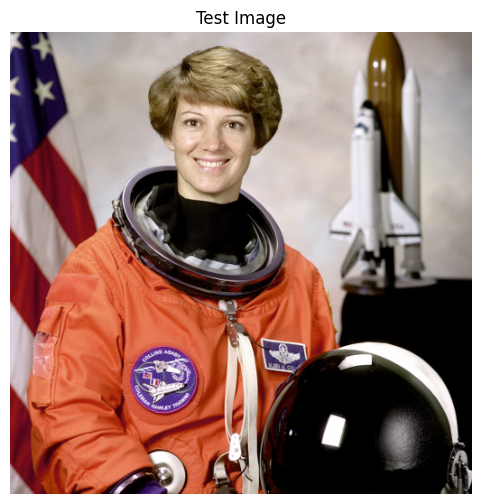

Image shape: (512, 512, 3)


In [2]:
seg_img = skdata.astronaut()  # (512, 512, 3) RGB uint8

plt.figure(figsize=(6, 6))
plt.imshow(seg_img)
plt.title('Test Image')
plt.axis('off')
plt.show()
print(f'Image shape: {seg_img.shape}')

### Baseline: K-means Segmentation

K-means clustering on RGB values directly (cf. L05 slides 8–13).

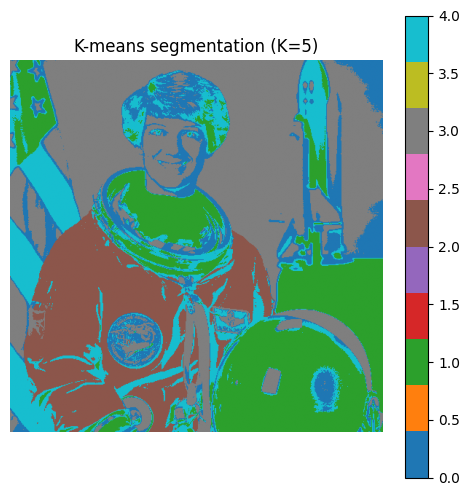

In [3]:
n_clusters = 5
labels_kmeans = kmeans(n_clusters, seg_img)

plt.figure(figsize=(6, 6))
plt.imshow(labels_kmeans, cmap='tab10')
plt.title(f'K-means segmentation (K={n_clusters})')
plt.colorbar()
plt.axis('off')
plt.show()

### [CP 1.1] Feature Space Construction (5%)

Each pixel becomes a 5D feature: `(spatial_weight * row, spatial_weight * col, R, G, B)` (L05 slides 14–16, 20).

**Implement `construct_feature_space(image, spatial_weight)` in `lab3.py`.**

In [4]:
spatial_weight = 0.5
features = construct_feature_space(seg_img, spatial_weight)

H, W, C = seg_img.shape
print(f'[CP 1.1] Feature shape:   {features.shape}')
print(f'[CP 1.1] Expected shape:  ({H * W}, 5)')
print(f'[CP 1.1] dtype: {features.dtype}')
print(f'[CP 1.1] Feature ranges:')
for i, name in enumerate(['sw*row', 'sw*col', 'R', 'G', 'B']):
    print(f'  {name}: [{features[:, i].min():.2f}, {features[:, i].max():.2f}]')

[CP 1.1] Feature shape:   (262144, 5)
[CP 1.1] Expected shape:  (262144, 5)
[CP 1.1] dtype: float64
[CP 1.1] Feature ranges:
  sw*row: [0.00, 255.50]
  sw*col: [0.00, 255.50]
  R: [0.00, 255.00]
  G: [0.00, 255.00]
  B: [0.00, 255.00]


### [CP 1.2] Mean-Shift Update Step (15%)

The mean-shift vector shifts a point toward the local density mode using a Gaussian kernel (L05 slides 30–32).

**Implement `mean_shift_step(data, point, bandwidth)` in `lab3.py`.**

In [5]:
test_point = features[0].copy()
bandwidth = 30.0

new_point1 = mean_shift_step(features, test_point, bandwidth)
shift1 = np.linalg.norm(new_point1 - test_point)

new_point2 = mean_shift_step(features, new_point1, bandwidth)
shift2 = np.linalg.norm(new_point2 - new_point1)

print(f'[CP 1.2] Original point:  {test_point}')
print(f'[CP 1.2] After step 1:    {new_point1}')
print(f'[CP 1.2] After step 2:    {new_point2}')
print(f'[CP 1.2] Shift 1: {shift1:.4f}')
print(f'[CP 1.2] Shift 2: {shift2:.4f}')
print(f'[CP 1.2] Converging: {shift2 < shift1}')

[CP 1.2] Original point:  [  0.   0. 154. 147. 151.]
[CP 1.2] After step 1:    [ 20.23419375  33.18727553 172.13521676 164.84013438 158.63514704]
[CP 1.2] After step 2:    [ 29.88160631  46.53061111 182.33229846 173.57507226 166.61405437]
[CP 1.2] Shift 1: 47.0773
[CP 1.2] Shift 2: 22.6949
[CP 1.2] Converging: True


### [CP 1.3] Mean-Shift Segmentation (15%)

Run iterative mean-shift for each point, then merge nearby modes (L05 slides 32, 34).

**Implement `mean_shift_segmentation(data, bandwidth, threshold, max_iter)` in `lab3.py`.**

*Tip:* Mean-Shift is expensive. We downscale by 8× for speed.

[CP 1.3] Small image: (64, 64, 3), features: (4096, 5)
[CP 1.3] Labels shape: (4096,)
[CP 1.3] Expected shape: (4096,)
[CP 1.3] Number of segments: 4


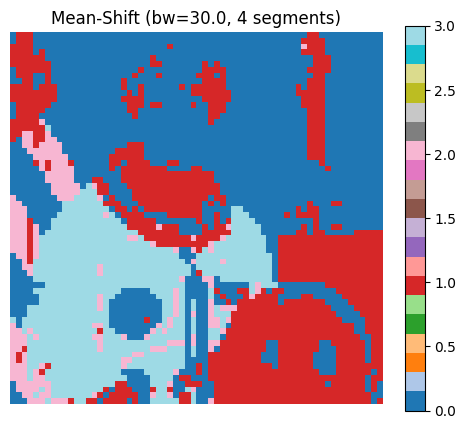

In [6]:
scale = 8
small_img = cv2.resize(seg_img, (seg_img.shape[1] // scale, seg_img.shape[0] // scale))
features_small = construct_feature_space(small_img, spatial_weight=0.5)
print(f'[CP 1.3] Small image: {small_img.shape}, features: {features_small.shape}')

bandwidth = 30.0
labels_ms = mean_shift_segmentation(features_small, bandwidth=bandwidth)

print(f'[CP 1.3] Labels shape: {labels_ms.shape}')
print(f'[CP 1.3] Expected shape: ({features_small.shape[0]},)')
print(f'[CP 1.3] Number of segments: {len(np.unique(labels_ms))}')

labels_ms_2d = labels_ms.reshape(small_img.shape[:2])
plt.figure(figsize=(6, 5))
plt.imshow(labels_ms_2d, cmap='tab20')
plt.title(f'Mean-Shift (bw={bandwidth}, {len(np.unique(labels_ms))} segments)')
plt.colorbar()
plt.axis('off')
plt.show()

### [CP 1.4] Bandwidth Experiment & Comparison (5%)

Try different bandwidth values and compare with K-means (L05 slides 17, 36).

[CP 1.4] bandwidth=15: 37 segments
[CP 1.4] bandwidth=30: 4 segments
[CP 1.4] bandwidth=60: 2 segments


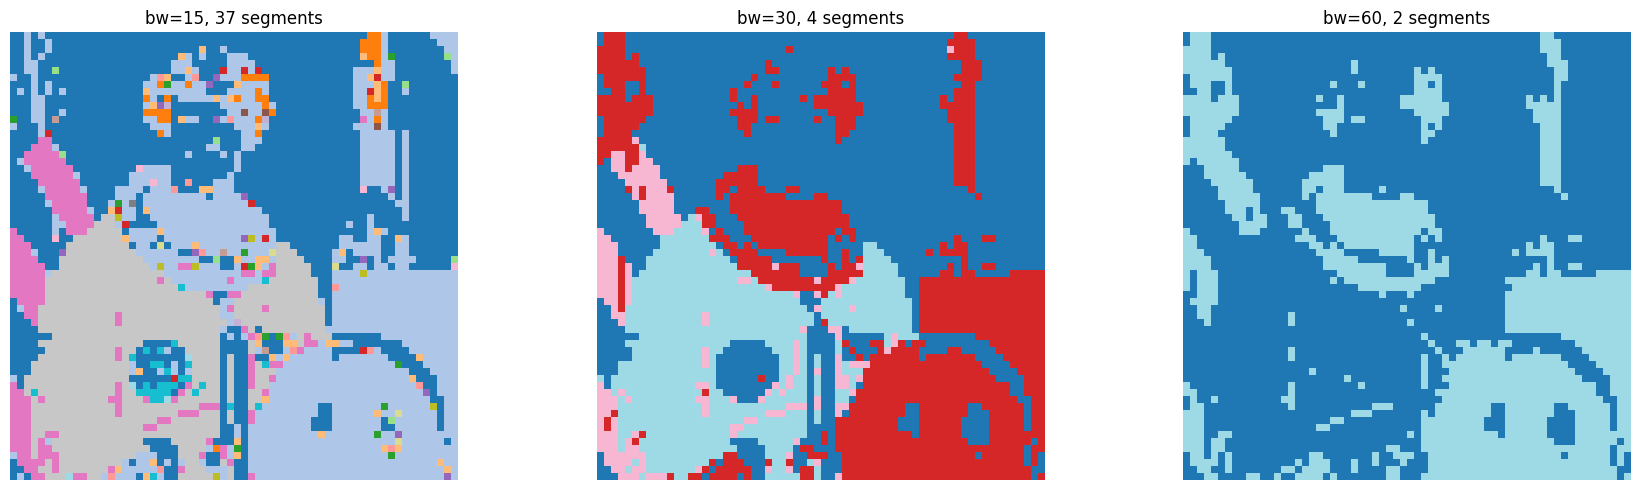

In [7]:
bandwidths = [15, 30, 60]
fig, axes = plt.subplots(1, len(bandwidths), figsize=(6 * len(bandwidths), 5))
for ax, bw in zip(axes, bandwidths):
    labels = mean_shift_segmentation(features_small, bandwidth=bw)
    labels_2d = labels.reshape(small_img.shape[:2])
    n_seg = len(np.unique(labels))
    ax.imshow(labels_2d, cmap='tab20')
    ax.set_title(f'bw={bw}, {n_seg} segments')
    ax.axis('off')
    print(f'[CP 1.4] bandwidth={bw}: {n_seg} segments')
plt.tight_layout()
plt.show()

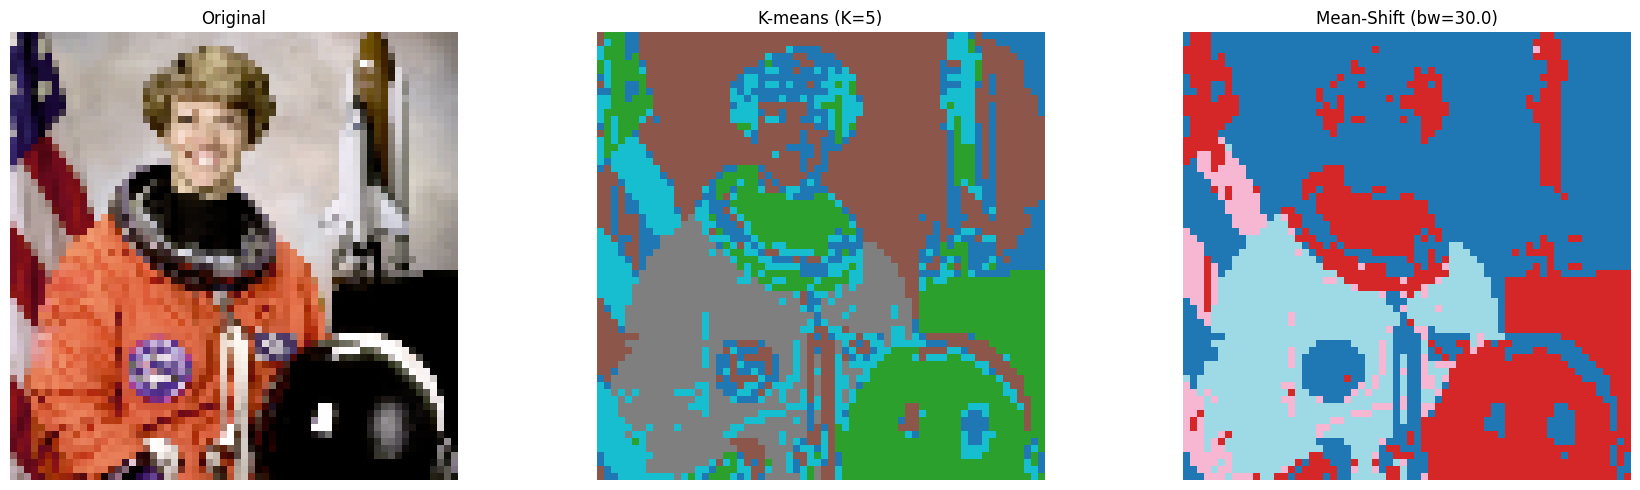

In [8]:
labels_km = kmeans(5, small_img)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(small_img)
axes[0].set_title('Original')
axes[0].axis('off')
axes[1].imshow(labels_km, cmap='tab10')
axes[1].set_title('K-means (K=5)')
axes[1].axis('off')
axes[2].imshow(labels_ms_2d, cmap='tab20')
axes[2].set_title(f'Mean-Shift (bw={bandwidth})')
axes[2].axis('off')
plt.tight_layout()
plt.show()

### [Q1] Bandwidth Effect (3%)

How does the `bandwidth` parameter affect the Mean-Shift segmentation result? Discuss its relationship to the number of segments discovered. (cf. L05 slide 36)

**Your Answer:**

A smaller bandwidth means the radius of the search window is smaller. This causes mean-shift algorithm to detect more fine-grained local density peaks, leading to many small segments discovered. Conversely, a larger bandwidth means the radius of the search window is larger. This merges local density peaks nearby together, resulting in a few large segments.

### [Q2] K-means vs Mean-Shift (2%)

Compare K-means and Mean-Shift segmentation results. What are the advantages and disadvantages of each method? (cf. L05 slides 17, 37)

**Your Answer:**

K-means produced 5 segments that map loosely to color regions with relatively weaker spatial coherence. It has noticeably more fragmented, scattered patches and the same cluster can appear anywhere. On the other hand, mean-shift produces relatively more spatially coherent regions but fine detail is lost due to the large bandwidth merging similar colors (e.g. most of the facial details are lost.)

K-means' advantages include outputting a predictable number of output segments as we control the `n_clusters` value and it is computationally efficient, scaling well to large images. However, specifying the most appropriate `n_clusters` value is not trivial, and its output is sensitive to where the centroids are initialized.

Conversely, mean-shift automatically determines the number of segments and makes no assumptions about cluster shape, making it better suited for irregular regions. Its limitations include high computational cost and strong sensitivity to the bandwidth parameter.

---
## Part 2: Texture Description and Segmentation (55%)

Textures can be represented by filter bank responses (L06 slides 14–15). Gabor filters capture oriented texture patterns (L06 slides 15–19). Textons are learned by clustering filter responses (L06 slides 22–23).

### [CP 2.1] Gabor Filter Construction (10%)

A Gabor filter = Gaussian envelope × sinusoidal wave, capturing texture at a specific orientation and scale (L06 slides 15–19, 38–39).

**Implement `create_gabor_filter(sigma, theta, lambd, psi)` in `lab3.py`.**

[CP 2.1] theta=    0 deg  shape=(25, 25)  sum=1.366214
[CP 2.1] theta=   45 deg  shape=(25, 25)  sum=2.428133
[CP 2.1] theta=   90 deg  shape=(25, 25)  sum=1.366214
[CP 2.1] theta=  135 deg  shape=(25, 25)  sum=2.428133


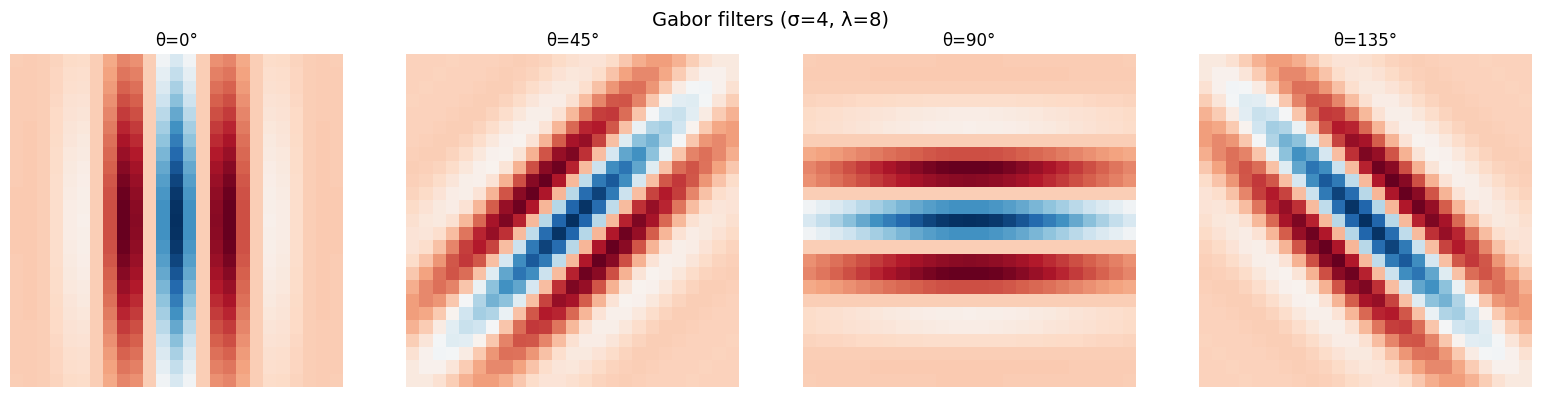

In [9]:
orientations = [0, np.pi/4, np.pi/2, 3*np.pi/4]
sigma, lambd = 4, 8

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, theta in zip(axes, orientations):
    kernel = create_gabor_filter(sigma=sigma, theta=theta, lambd=lambd)
    print(f'[CP 2.1] theta={np.degrees(theta):5.0f} deg  shape={kernel.shape}  sum={kernel.sum():.6f}')
    ax.imshow(kernel, cmap='RdBu')
    ax.set_title(f'\u03b8={np.degrees(theta):.0f}\u00b0')
    ax.axis('off')
plt.suptitle(f'Gabor filters (\u03c3={sigma}, \u03bb={lambd})', fontsize=14)
plt.tight_layout()
plt.show()

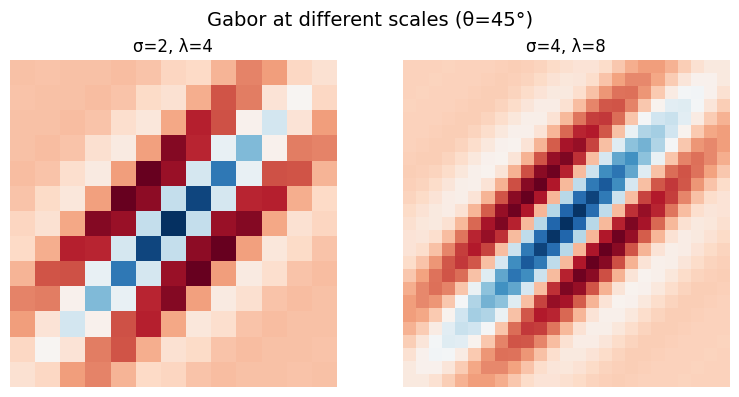

In [10]:
scales = [(2, 4), (4, 8)]
theta = np.pi / 4

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
for ax, (s, l) in zip(axes, scales):
    kernel = create_gabor_filter(sigma=s, theta=theta, lambd=l)
    ax.imshow(kernel, cmap='RdBu')
    ax.set_title(f'\u03c3={s}, \u03bb={l}')
    ax.axis('off')
plt.suptitle('Gabor at different scales (\u03b8=45\u00b0)', fontsize=14)
plt.tight_layout()
plt.show()

### [CP 2.2] Laplacian of Gaussian Filter (5%)

LoG detects "spot"-like patterns (cf. L06 slide 15).

**Implement `create_log_filter(sigma)` in `lab3.py`.**

[CP 2.2] sigma=1  shape=(7, 7)  sum=-0.008172
[CP 2.2] sigma=2  shape=(13, 13)  sum=-0.006080
[CP 2.2] sigma=4  shape=(25, 25)  sum=-0.002316
[CP 2.2] sigma=8  shape=(49, 49)  sum=-0.000697


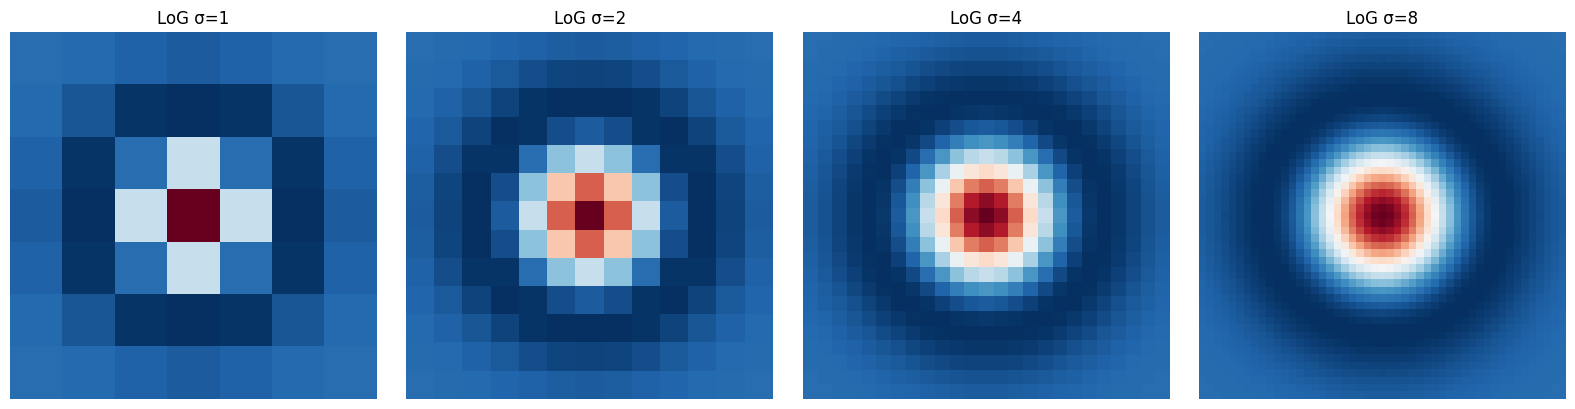

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, sigma in zip(axes, [1, 2, 4, 8]):
    kernel = create_log_filter(sigma)
    print(f'[CP 2.2] sigma={sigma}  shape={kernel.shape}  sum={kernel.sum():.6f}')
    ax.imshow(kernel, cmap='RdBu')
    ax.set_title(f'LoG \u03c3={sigma}')
    ax.axis('off')
plt.tight_layout()
plt.show()

### [CP 2.3] Filter Bank Response Extraction (10%)

Build a 12D filter bank and extract per-pixel responses (L06 slides 14–15, 19–20):
- Gabor: 4 orientations (0°, 45°, 90°, 135°) × 2 scales (σ=2,λ=4 and σ=4,λ=8) → **8 responses**
- LoG: 4 scales (σ=1, 2, 4, 8) → **4 responses**

**Implement `build_filter_bank_responses(image, filter_bank)` in `lab3.py`.**

**Hint:** Use `scipy.ndimage.convolve` (already imported in `lab3.py`) to apply each filter kernel:
```python
from scipy.ndimage import convolve
response = convolve(gray_image, kernel, mode='reflect')  # gray_image: (H,W), kernel: (K,K) → response: (H,W)
```

In [12]:
orientations = [0, np.pi/4, np.pi/2, 3*np.pi/4]
gabor_params = [(2, t, 4) for t in orientations] + [(4, t, 8) for t in orientations]
log_sigmas = [1, 2, 4, 8]

filter_bank = []
for (s, t, l) in gabor_params:
    filter_bank.append(create_gabor_filter(s, t, l))
for s in log_sigmas:
    filter_bank.append(create_log_filter(s))

print(f'Filter bank: {len(filter_bank)} filters (8 Gabor + 4 LoG = 12D features)')

Filter bank: 12 filters (8 Gabor + 4 LoG = 12D features)


[CP 2.3] Response shape:  (512, 512, 12)
[CP 2.3] Expected shape:  (512, 512, 12)


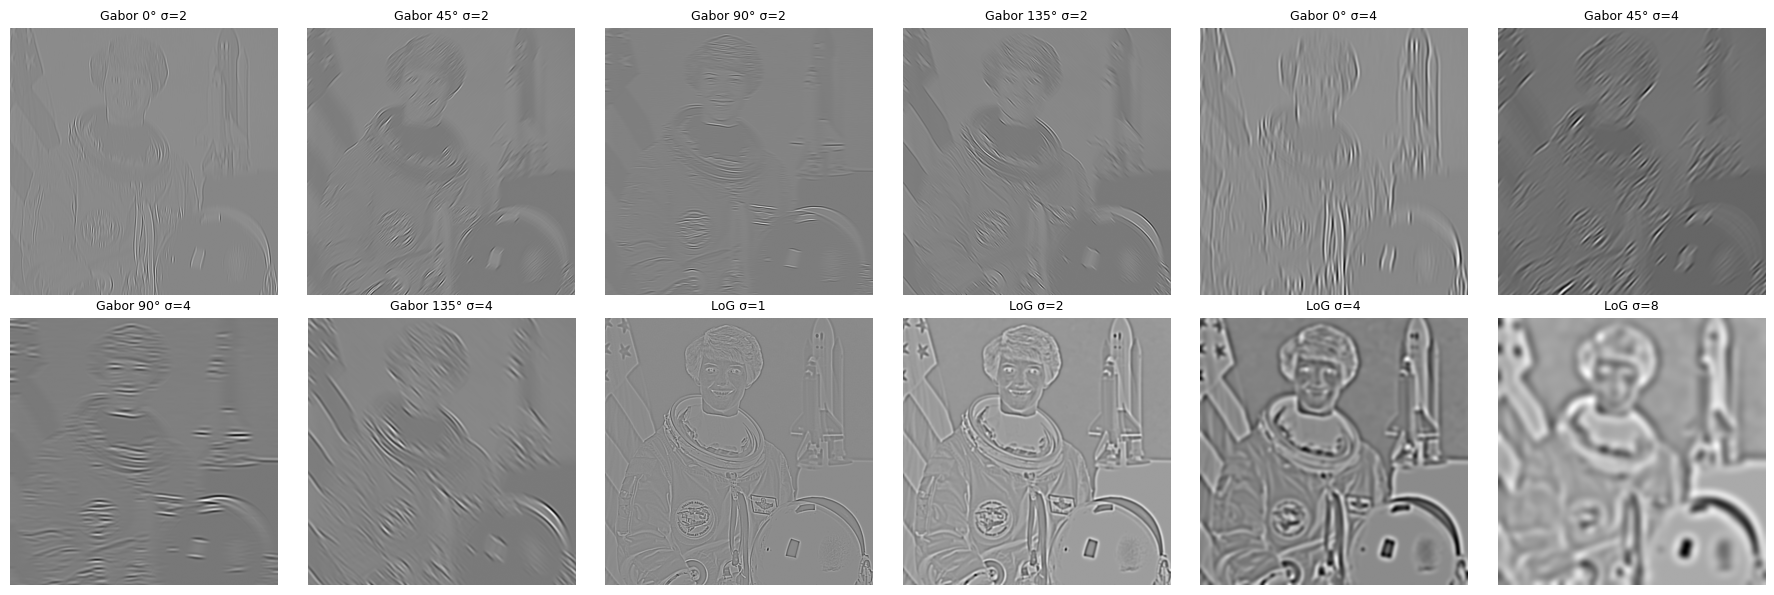

In [13]:
feats = build_filter_bank_responses(seg_img, filter_bank)
print(f'[CP 2.3] Response shape:  {feats.shape}')
print(f'[CP 2.3] Expected shape:  ({seg_img.shape[0]}, {seg_img.shape[1]}, 12)')

fig, axes = plt.subplots(2, 6, figsize=(18, 6))
channel_names = (
    [f'Gabor {d}\u00b0 \u03c3={s}' for s in [2, 4] for d in [0, 45, 90, 135]]
    + [f'LoG \u03c3={s}' for s in [1, 2, 4, 8]]
)
for i in range(12):
    ax = axes[i // 6, i % 6]
    ax.imshow(feats[:, :, i], cmap='gray')
    ax.set_title(channel_names[i], fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()

### [CP 2.4] Texton Dictionary Learning (10%)

Learn a texton dictionary by clustering filter responses from training images (L06 slides 22–23, 36).

**Implement `TextonDictionary.learn_dictionary()` and `TextonDictionary.assign_textons()` in `lab3.py`.**

#### API Reference

**`MiniBatchKMeans`** — efficient K-means clustering (`sklearn.cluster`, already imported in `lab3.py`):
```python
from sklearn.cluster import MiniBatchKMeans

kmeans = MiniBatchKMeans(n_clusters=200, random_state=0, batch_size=1000)
kmeans.fit(data)               # data: np.array of shape (N, D)
centers = kmeans.cluster_centers_  # result: (n_clusters, D)
```

**`KDTree`** — fast nearest-neighbor lookup (`sklearn.neighbors`, already imported in `lab3.py`):
```python
from sklearn.neighbors import KDTree

tree = KDTree(centers)                        # build tree from (n_clusters, D)
distances, indices = tree.query(points, k=1)  # points: (N, D) → indices: (N, 1)
nearest_id = indices.flatten()                # (N,) array of nearest cluster IDs
```

You could find more details from the online resources.

**Workflow:**
1. `learn_dictionary()`: extract filter bank responses from each training image → collect all pixel features → fit `MiniBatchKMeans` → store `self.cluster_centers_` and build `self.tree_ = KDTree(self.cluster_centers_)`.
2. `assign_textons()`: extract filter bank responses → reshape to (H\*W, D) → `self.tree_.query(...)` → reshape indices to (H, W).

In [14]:
data_dir = 'MSRC_v2'
train_list_path = 'Train.txt'

training_imgs = []
if os.path.exists(train_list_path) and os.path.isdir(data_dir):
    train_list = open(train_list_path).read().strip().split('\n')
    train_subset = train_list[:20]
    training_imgs = [
        cv2.cvtColor(cv2.imread(os.path.join(data_dir, f)), cv2.COLOR_BGR2RGB)
        for f in tqdm(train_subset, desc='Loading training images')
        if os.path.exists(os.path.join(data_dir, f))
    ]

if len(training_imgs) == 0:
    print('WARNING: Training data not found. Using test image as fallback.')
    training_imgs = [seg_img]
else:
    print(f'Loaded {len(training_imgs)} training images.')

Loading training images: 100%|██████████| 20/20 [00:00<00:00, 1301.65it/s]

Loaded 20 training images.


[CP 2.4] Dictionary learned successfully
[CP 2.4] Texton map shape: (512, 512)
[CP 2.4] Expected shape:   (512, 512)
[CP 2.4] Unique textons:   200
[CP 2.4] Texton ID range:  [0, 199]
[CP 2.4] Valid (0 to 199): True


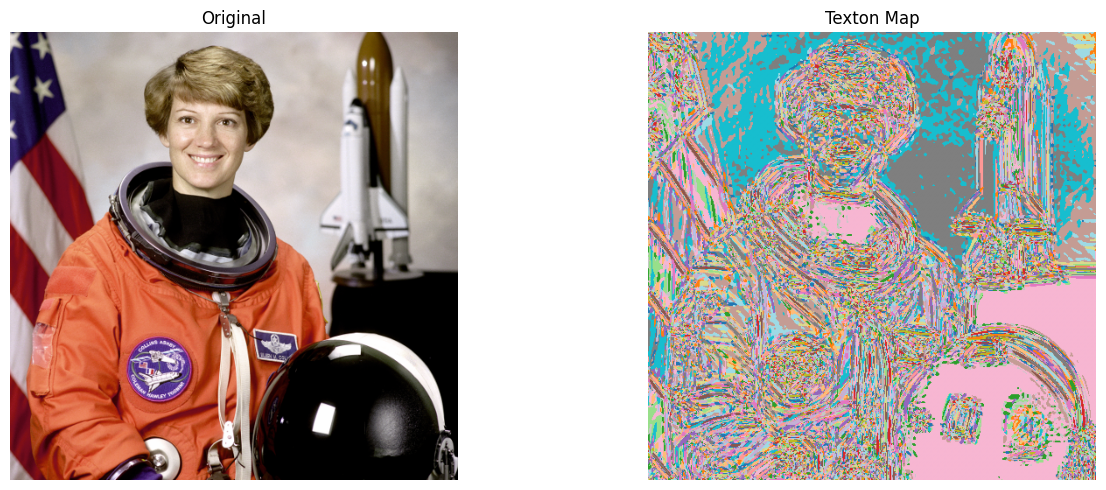

In [15]:
n_textons = 200
texton_dict = TextonDictionary(filter_bank, n_textons=n_textons)
texton_dict.learn_dictionary(training_imgs)
print(f'[CP 2.4] Dictionary learned successfully')

texton_map = texton_dict.assign_textons(seg_img)
print(f'[CP 2.4] Texton map shape: {texton_map.shape}')
print(f'[CP 2.4] Expected shape:   ({seg_img.shape[0]}, {seg_img.shape[1]})')
print(f'[CP 2.4] Unique textons:   {len(np.unique(texton_map))}')
print(f'[CP 2.4] Texton ID range:  [{texton_map.min()}, {texton_map.max()}]')
print(f'[CP 2.4] Valid (0 to {n_textons-1}): {texton_map.min() >= 0 and texton_map.max() < n_textons}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(seg_img)
axes[0].set_title('Original')
axes[0].axis('off')
axes[1].imshow(texton_map, cmap='tab20')
axes[1].set_title('Texton Map')
axes[1].axis('off')
plt.tight_layout()
plt.show()

### [CP 2.5] Texton Histogram (10%)

Compute per-pixel texton histogram within a rectangular window for a robust texture descriptor (L06 slides 24–26, 37).

**Implement `compute_texton_histogram(texton_map, n_textons, window_size)` in `lab3.py`.**

In [16]:
window_size = 7
histogram_feat = compute_texton_histogram(texton_map, n_textons=n_textons, window_size=window_size)

print(f'[CP 2.5] Histogram shape: {histogram_feat.shape}')
print(f'[CP 2.5] Expected shape:  ({seg_img.shape[0]}, {seg_img.shape[1]}, {n_textons})')

sums = histogram_feat.sum(axis=2)
print(f'[CP 2.5] Histogram sum range:     [{sums.min():.6f}, {sums.max():.6f}]')
print(f'[CP 2.5] All histograms sum to 1: {np.allclose(sums, 1.0)}')

[CP 2.5] Histogram shape: (512, 512, 200)
[CP 2.5] Expected shape:  (512, 512, 200)
[CP 2.5] Histogram sum range:     [1.000000, 1.000000]
[CP 2.5] All histograms sum to 1: True


### [CP 2.6] Texture-Based Segmentation (5%)

Compare two texture feature approaches for K-means segmentation (L06 slide 37):
- **(B)** Spatially smoothed filter bank responses
- **(C)** Texton histograms

[CP 2.6] Method B segments: 5
[CP 2.6] Method C segments: 5


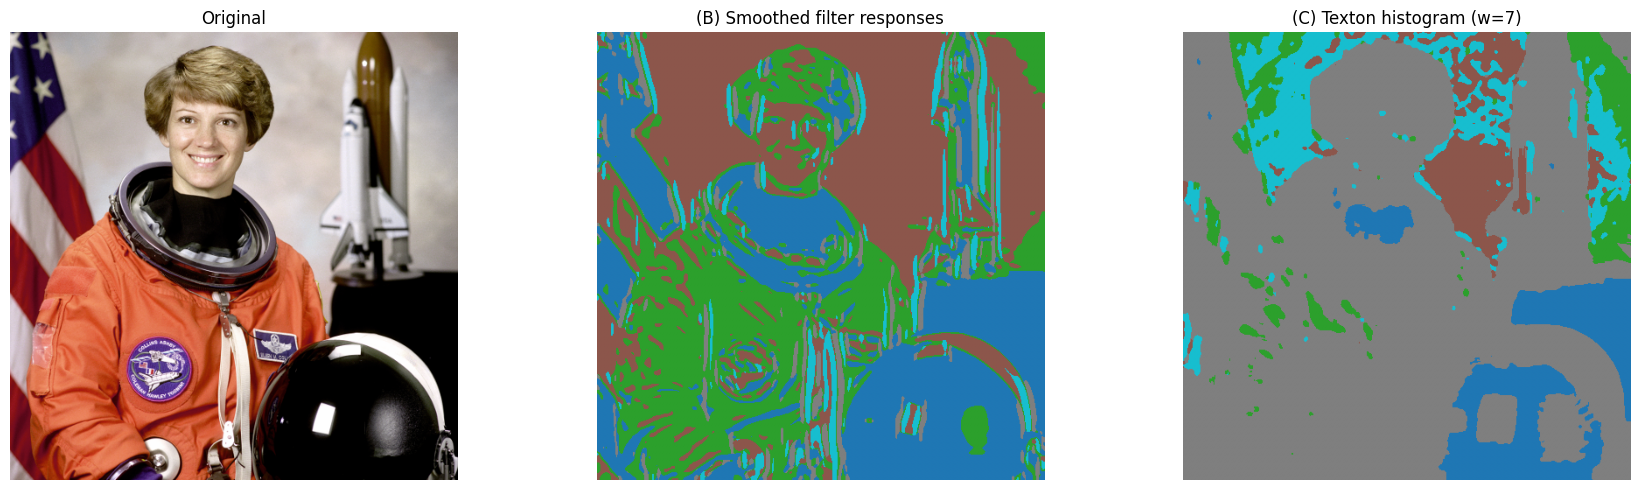

In [17]:
from scipy.ndimage import gaussian_filter
from sklearn.cluster import KMeans

# Method B: spatially smoothed filter responses
smooth_sigma = 3
smoothed_feats = np.stack(
    [gaussian_filter(feats[:, :, i], sigma=smooth_sigma) for i in range(feats.shape[2])],
    axis=-1
)
H, W, D = smoothed_feats.shape
labels_B = KMeans(n_clusters=5, random_state=0, n_init='auto').fit_predict(
    smoothed_feats.reshape(-1, D)
).reshape(H, W)

# Method C: texton histograms
H, W, D = histogram_feat.shape
labels_C = KMeans(n_clusters=5, random_state=0, n_init='auto').fit_predict(
    histogram_feat.reshape(-1, D)
).reshape(H, W)

print(f'[CP 2.6] Method B segments: {len(np.unique(labels_B))}')
print(f'[CP 2.6] Method C segments: {len(np.unique(labels_C))}')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(seg_img)
axes[0].set_title('Original')
axes[0].axis('off')
axes[1].imshow(labels_B, cmap='tab10')
axes[1].set_title('(B) Smoothed filter responses')
axes[1].axis('off')
axes[2].imshow(labels_C, cmap='tab10')
axes[2].set_title(f'(C) Texton histogram (w={window_size})')
axes[2].axis('off')
plt.tight_layout()
plt.show()

### [Q3] Window Size Effect (2%)

How does the `window_size` parameter in the texton histogram affect the segmentation result? Analyze the trade-off between segmentation smoothness and boundary precision. (cf. L06 slide 37)

**Your Answer:**

The window_size parameter controls the scale at which texture histograms are computed around each pixel. With a small window, the histogram is built from very few pixels and the feature representation is noisy and unstable. This produces fragmented segments but preserves boundary precision since the window stays largely within a single region. However, with a large window, the histogram aggregates textons over a broader area, producing smooth and stable features that yield coherent segments. However, windows near region boundaries will straddle two different textures, mixing their distributions and causing the boundaries to blur. This will cause a reduction in boundary precision.

### [Q4] Method B vs C (1%)

Compare segmentation using smoothed filter responses (option B) versus texton histograms (option C). Which gives better boundary precision, and why? (cf. L06 slide 37 note)

**Your Answer:**

Smoothed filter responses gives better boundary precision.

Smoothed filter responses preserve the spatial ordering of pixels as each pixel's feature vector is a smoothed version of its filter responses, meaning nearby pixels have similar but still spatially distinct features that reflect their actual position in the image. Boundaries are captured where these responses change abruptly, hence giving relatively good boundary precision.

Texton histograms discard spatial order entirely within the window as it only counts how many of each texton ID appear in the neighborhood, treating the window as a bag of textons with no regard for where within the window each texton falls. Boundary precision is thus worse because spatial arrangement information is loss during histogram pooling. 

### [Q5] Gabor Orientations (2%)

Examine the Gabor filter responses at different orientations. How do different θ values capture different texture patterns? Give a concrete example from your test image. (cf. L06 slides 17, 19)

**Your Answer:**

θ = 0 degrees captures vertical edges as the sinusoidal bands run top-down. θ = 45 degrees captures diagonal edges from bottom-left to top-right. θ = 90 degrees captures horizontal edges and θ = 135 degrees captures diagonal edges from top-left to bottom-right.

As a concrete example, the θ = 0 degrees filter would fire strongly along the vertical edges of the shuttle structure in the background

---
*Congratulations! You have reached the end of Lab 3.*